# Geospatial Machine Learning — Part 4: Random Forest with Spatial Cross-Validation

This notebook repeats the Random Forest model of Part 3, changing only **how the data are split** for validation.

**Why spatial cross-validation?** Part 2 showed that sand content is spatially autocorrelated: nearby samples have similar values. With a random split (Part 3), most test samples have a training sample a few kilometers away, so the model is evaluated on locations it has practically already seen. The resulting metrics are optimistic, especially if the map is used to predict regions with few or no samples.

**Spatial blocking.** Here the study area is divided into 2° × 2° blocks (~220 km). Whole blocks are assigned either to training or to testing, and whole training blocks are assigned to cross-validation folds. Each test sample is therefore at least part of a block away from the training data, which mimics prediction in unsampled regions.

**Workflow**

1. Load the sample data
2. Load the raster predictors
3. Extract raster values at sample locations
4. Prepare the modeling dataset
5. Create 2° × 2° spatial blocks
6. Create spatial training and independent test sets
7. Assign training blocks to 10 spatial folds
8. Diagnose and visualize the spatial folds
9. Build explicit scikit-learn spatial CV indices
10. Tune the Random Forest with spatial cross-validation
11. Evaluate spatial cross-validation performance
12. Examine variable importance
13. Predict the independent spatial test data
14. Evaluate the independent spatial test
15. Compare observed and predicted values
16. Apply the model to the raster predictors and save the prediction map
17. Display the prediction map
18. Final spatial-CV checks

The prediction map is saved to `output/pred_areia_rf_spatialcv.tif`, so it does not overwrite the map from Part 3.

In [1]:
# Import libraries.
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio

from shapely.geometry import box

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_predict, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

## 1. Load the sample data

Samples made only of coarse fragments (`esqueleto` = 1000 g/kg) are removed, because their sand value of 0 is not a real measurement.

In [2]:
# Input data and outputs are kept in separate folders next to this notebook.
INPUT_DIR = Path("input")
OUTPUT_DIR = Path("output")

# Define the sample-data path.
samples_path = INPUT_DIR / "c3_soildata_psd_modeling_0_50cm.gpkg"

# Read sample points.
samples = gpd.read_file(samples_path)

# Drop layers made only of coarse fragments (esqueleto = 1000 g/kg).
# They contain no fine earth, so sand = 0 there is not a measurement.
samples = samples[samples["esqueleto"] < 1000].reset_index(drop=True)
print("Samples after removing esqueleto = 1000:", len(samples))

samples.info()
display(samples.head())
display(samples.describe(include="all"))

Samples after removing esqueleto = 1000: 14165
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 14165 entries, 0 to 14164
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   id                        14165 non-null  str     
 1   longitude                 14165 non-null  float64 
 2   latitude                  14165 non-null  float64 
 3   profundidade              14165 non-null  float64 
 4   esqueleto                 14165 non-null  int32   
 5   areia                     14165 non-null  int32   
 6   silte                     14165 non-null  int32   
 7   argila                    14165 non-null  int32   
 8   log_silte1p_argila1p      14165 non-null  float64 
 9   log_areia1p_argila1p      14165 non-null  float64 
 10  log_esqueleto1p_argila1p  14165 non-null  float64 
 11  geometry                  14165 non-null  geometry
dtypes: float64(6), geometry(1), int32(4), str(1)
me

,id,longitude,latitude,profundidade,esqueleto,areia,silte,argila,log_silte1p_argila1p,log_areia1p_argila1p,log_esqueleto1p_argila1p,geometry
0,clay-copy-ctb0004-RosĂˇrio-26,-35.134160,-8.576835,40.0,0,200,150,650,-1.461230,-1.175205,-6.478510,POINT (-35.13416 -8.57683)
1,clay-copy-ctb0019-P1,-50.231766,-29.475679,44.0,0,120,250,630,-0.921853,-1.651515,-6.447306,POINT (-50.23177 -29.47568)
2,clay-copy-ctb0033-RO1271,-64.059444,-11.770000,50.0,0,157,67,776,-2.435933,-1.592845,-6.655440,POINT (-64.05944 -11.77)
3,clay-copy-ctb0033-RO1279,-64.330278,-12.018333,45.0,0,60,200,740,-1.304696,-2.497127,-6.608001,POINT (-64.33028 -12.01833)
4,clay-copy-ctb0033-RO1303,-63.941667,-9.891667,45.0,400,260,70,670,-2.237736,-0.942691,-0.004975,POINT (-63.94167 -9.89167)


,id,longitude,latitude,profundidade,esqueleto,areia,silte,argila,log_silte1p_argila1p,log_areia1p_argila1p,log_esqueleto1p_argila1p,geometry
count,14165,14165.000000,14165.000000,14165.000000,14165.000000,14165.000000,14165.000000,14165.000000,14165.000000,14165.000000,14165.000000,14165
unique,14057,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14165
top,clay-copy-ctb0033-RO2493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-35.13416003624 -8.576834933487826)
freq,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
mean,NaN,-53.621213,-16.082803,24.697653,64.939287,484.000424,182.003318,333.996258,-0.627611,0.498344,-3.082999,NaN
std,NaN,8.079586,8.481977,14.933753,110.124817,277.086129,140.243171,215.486282,0.918257,1.954324,2.578236,NaN
min,NaN,-73.850000,-33.686969,0.500000,0.000000,0.000000,0.000000,0.000000,-6.673298,-6.792344,-6.888572,NaN
25%,NaN,-61.150000,-22.501390,10.000000,0.000000,249.000000,77.000000,150.000000,-1.252763,-0.660357,-5.564520,NaN
50%,NaN,-54.150000,-15.936090,22.500000,10.000000,483.000000,144.000000,300.000000,-0.707513,0.423050,-3.209306,NaN
75%,NaN,-47.316670,-9.900021,39.000000,118.000000,710.000000,260.000000,492.000000,0.000000,1.474801,-0.796944,NaN


## 2. Load the raster predictors

Every GeoTIFF in the `input` folder is used as a predictor, and its file name becomes the variable name.

In [3]:
# Define the predictor directory.
workdir_xvars = INPUT_DIR

# List GeoTIFF predictors.
raster_files = sorted(workdir_xvars.glob("*.tif"))

print(f"Number of raster predictors: {len(raster_files)}")
for f in raster_files:
    print(f.name)

Number of raster predictors: 25
HAND.tif
Mean_curvature.tif
NTSI.tif
TPI_11x11.tif
bio1.tif
bio10.tif
bio11.tif
bio12.tif
bio13.tif
bio14.tif
bio15.tif
bio16.tif
bio17.tif
bio18.tif
bio19.tif
bio2.tif
bio3.tif
bio4.tif
bio5.tif
bio6.tif
bio7.tif
bio8.tif
bio9.tif
elevation.tif
slope.tif


In [4]:
# Use file stems as predictor names.
raster_names = [f.stem for f in raster_files]

raster_names

['HAND',
 'Mean_curvature',
 'NTSI',
 'TPI_11x11',
 'bio1',
 'bio10',
 'bio11',
 'bio12',
 'bio13',
 'bio14',
 'bio15',
 'bio16',
 'bio17',
 'bio18',
 'bio19',
 'bio2',
 'bio3',
 'bio4',
 'bio5',
 'bio6',
 'bio7',
 'bio8',
 'bio9',
 'elevation',
 'slope']

## 3. Extract raster values at sample locations

The samples must be in geographic coordinates (degrees), because the spatial blocks are defined as 2° × 2° cells.

In [5]:
# Check sample and raster CRS.
with rasterio.open(raster_files[0]) as src:
    raster_crs = src.crs

print("Sample CRS:", samples.crs)
print("Raster CRS:", raster_crs)

# Match the raster CRS.
if samples.crs != raster_crs:
    samples = samples.to_crs(raster_crs)

# Spatial blocks are defined in degrees.
if not samples.crs.is_geographic:
    raise ValueError(
        "The sample CRS must be geographic to create 2° x 2° blocks."
    )

Sample CRS: EPSG:4326
Raster CRS: EPSG:4326


In [6]:
# Extract raster values at sample locations.
coords = [(geom.x, geom.y) for geom in samples.geometry]

for raster_path, raster_name in zip(raster_files, raster_names):
    with rasterio.open(raster_path) as src:
        values = [v[0] for v in src.sample(coords)]

        if src.nodata is not None:
            values = [
                np.nan if v == src.nodata else v
                for v in values
            ]

        samples[raster_name] = values

display(samples.head())

,id,longitude,latitude,profundidade,esqueleto,areia,silte,argila,log_silte1p_argila1p,log_areia1p_argila1p,...,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,elevation,slope
0,clay-copy-ctb0004-RosĂˇrio-26,-35.134160,-8.576835,40.0,0,200,150,650,-1.461230,-1.175205,...,6.566667,69.122803,105.115379,29.000000,19.500000,9.500000,23.566666,24.783333,36.0,0.960910
1,clay-copy-ctb0019-P1,-50.231766,-29.475679,44.0,0,120,250,630,-0.921853,-1.651515,...,8.783334,51.364521,305.108032,23.600000,6.500000,17.100000,18.783333,15.983334,916.0,0.110330
2,clay-copy-ctb0033-RO1271,-64.059444,-11.770000,50.0,0,157,67,776,-2.435933,-1.592845,...,11.125000,73.190796,67.367989,33.099998,17.900000,15.199999,26.150000,25.166666,158.0,0.515958
3,clay-copy-ctb0033-RO1279,-64.330278,-12.018333,45.0,0,60,200,740,-1.304696,-2.497127,...,10.850000,73.809525,69.870026,33.000000,18.299999,14.700001,26.366667,25.333334,148.0,0.137899
4,clay-copy-ctb0033-RO1303,-63.941667,-9.891667,45.0,400,260,70,670,-2.237736,-0.942691,...,11.691667,72.619049,53.262882,33.500000,17.400000,16.100000,25.783333,25.100000,163.0,0.343252


## 4. Prepare the modeling dataset

Only the response and the raster predictors are kept, and incomplete samples are removed. A second table (`samples_model`) keeps the geometry of the same samples, aligned row by row, because it is needed to build the spatial blocks.

In [7]:
# Remove non-predictor variables.
columns_to_remove = [
    "id",
    "longitude",
    "latitude",
    "profundidade",
    "esqueleto",
    "silte",
    "argila",
    "log_silte1p_argila1p",
    "log_areia1p_argila1p",
    "log_esqueleto1p_argila1p",
]

samples_df = samples.drop(columns="geometry").copy()

samples_df = samples_df.drop(
    columns=[c for c in columns_to_remove if c in samples_df.columns]
)

print("Number of samples before removing NA:", len(samples_df))

# Keep complete observations only.
complete_idx = samples_df.notna().all(axis=1)

samples_df = samples_df.loc[complete_idx].copy()
samples_model = samples.loc[complete_idx].copy()

# Reset indices to keep all objects aligned.
samples_df = samples_df.reset_index(drop=True)
samples_model = samples_model.reset_index(drop=True)

print("Number of complete samples:", len(samples_df))

display(samples_df.head())
display(samples_df.describe())

Number of samples before removing NA: 14165
Number of complete samples: 13636


,areia,HAND,Mean_curvature,NTSI,TPI_11x11,bio1,bio10,bio11,bio12,bio13,...,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,elevation,slope
0,200,29.005001,-4.573328e-06,0.000083,-6.528925,24.391666,25.516666,22.983334,2119.0,328.0,...,6.566667,69.122803,105.115379,29.000000,19.500000,9.500000,23.566666,24.783333,36.0,0.960910
1,120,773.000000,9.522858e-06,-0.001479,173.289261,14.950000,18.783333,11.350000,1997.0,191.0,...,8.783334,51.364521,305.108032,23.600000,6.500000,17.100000,18.783333,15.983334,916.0,0.110330
2,157,0.000000,-8.854991e-06,0.005365,-16.669422,25.970833,26.666666,24.983334,1583.0,253.0,...,11.125000,73.190796,67.367989,33.099998,17.900000,15.199999,26.150000,25.166666,158.0,0.515958
3,60,0.000000,-2.143425e-07,0.003746,-11.256198,26.200001,26.950001,25.200001,1555.0,251.0,...,10.850000,73.809525,69.870026,33.000000,18.299999,14.700001,26.366667,25.333334,148.0,0.137899
4,260,38.011002,6.404418e-07,-0.003907,-0.975207,25.712500,26.283335,24.966667,2036.0,320.0,...,11.691667,72.619049,53.262882,33.500000,17.400000,16.100000,25.783333,25.100000,163.0,0.343252


,areia,HAND,Mean_curvature,NTSI,TPI_11x11,bio1,bio10,bio11,bio12,bio13,...,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,elevation,slope
count,13636.000000,13636.000000,1.363600e+04,13636.000000,13636.000000,13636.000000,13636.000000,13636.000000,13636.000000,13636.000000,...,13636.000000,13636.000000,13636.000000,13636.000000,13636.000000,13636.000000,13636.000000,13636.000000,13636.000000,13636.000000
mean,470.836169,109.073753,3.513821e-07,0.001952,1.799722,22.960907,24.806702,20.749161,1645.977295,253.691849,...,11.321078,66.241867,170.198074,31.237543,13.846582,17.390957,23.347353,21.724951,361.772954,1.190148
std,269.057196,152.347961,2.467508e-05,0.009556,44.347252,3.126982,2.088981,4.399317,394.786865,69.592743,...,1.385623,8.933483,118.877693,2.453016,4.310484,2.904920,3.428816,4.010433,311.814036,1.559417
min,0.000000,0.000000,-1.851026e-04,-0.064239,-389.107452,9.283334,11.466667,6.766666,379.000000,64.000000,...,6.216667,40.659340,23.880211,16.600000,-1.300000,9.099998,10.933333,6.766666,1.000000,0.000000
25%,240.000000,20.000000,-7.082996e-06,-0.001158,-13.090909,20.045834,23.700001,16.799999,1457.000000,190.000000,...,10.475000,61.056914,64.402494,30.200001,9.900000,15.900000,22.266666,18.816668,132.000000,0.321978
50%,471.500000,50.001999,6.856626e-12,0.001107,-0.421488,24.004168,25.200001,22.408334,1634.000000,262.000000,...,11.500000,68.404625,156.166199,31.700001,14.600000,18.100000,24.733334,22.850000,243.500000,0.689051
75%,690.000000,136.003242,8.164782e-06,0.002972,14.274793,25.370832,26.283333,24.466667,1853.000000,311.000000,...,12.441667,71.421265,235.627792,33.200001,17.000000,19.100002,25.666666,24.783333,530.000000,1.369471
max,1000.000000,2046.005981,2.857003e-04,0.157383,591.388428,28.066666,29.483334,27.266666,3624.000000,585.000000,...,15.208334,90.591385,461.137207,36.400002,22.900000,24.200001,28.166666,28.466667,2666.000000,17.405693


In [8]:
# Convert sand content to percent.
samples_df["areia"] = samples_df["areia"] / 10

# Add a permanent observation ID.
samples_model["obs_id"] = np.arange(len(samples_model))

## 5. Create the spatial blocks

The strategy follows the R reference implementation used in the course:

- fixed 2° × 2° geographic blocks;
- complete blocks assigned to training or independent test;
- about 30 % of observations reserved for the spatial test;
- training blocks assigned to 10 spatial folds;
- complete blocks remain together within each fold.

Each sample receives the identifier of the block that contains it.

In [9]:
# ============================================================
# CREATE SPATIAL BLOCKS
# ============================================================

block_size = 2.0

# Extract point coordinates.
samples_model["longitude_cv"] = samples_model.geometry.x
samples_model["latitude_cv"] = samples_model.geometry.y

# Anchor the grid at a multiple of 2 degrees.
origin_lon = (
    np.floor(samples_model["longitude_cv"].min() / block_size)
    * block_size
)
origin_lat = (
    np.floor(samples_model["latitude_cv"].min() / block_size)
    * block_size
)

# Assign each sample to one block.
samples_model["block_col"] = np.floor(
    (samples_model["longitude_cv"] - origin_lon) / block_size
).astype(int)

samples_model["block_row"] = np.floor(
    (samples_model["latitude_cv"] - origin_lat) / block_size
).astype(int)

samples_model["block_id"] = (
    "B_"
    + samples_model["block_col"].astype(str)
    + "_"
    + samples_model["block_row"].astype(str)
)

print("Grid origin:", origin_lon, origin_lat)
print("Total samples:", len(samples_model))
print("Occupied spatial blocks:", samples_model["block_id"].nunique())

Grid origin: -74.0 -34.0
Total samples: 13636
Occupied spatial blocks: 198


In [10]:
# Create occupied block polygons.
block_index = (
    samples_model[
        ["block_id", "block_col", "block_row"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

block_index["geometry"] = [
    box(
        origin_lon + col * block_size,
        origin_lat + row * block_size,
        origin_lon + (col + 1) * block_size,
        origin_lat + (row + 1) * block_size,
    )
    for col, row in zip(
        block_index["block_col"],
        block_index["block_row"]
    )
]

blocks_gdf = gpd.GeoDataFrame(
    block_index,
    geometry="geometry",
    crs=samples_model.crs
)

## 6. Create spatial training and independent test sets

Blocks are shuffled and added to the test set until it holds about 30 % of the samples. At least 10 blocks are kept for training so that 10 folds can be formed. A check confirms that no block appears in both sets.

In [11]:
# ============================================================
# SPATIAL TRAIN / TEST SPLIT
# ============================================================

test_fraction = 0.30
k_folds = 10
random_state = 123

# Count samples per block.
block_counts = (
    samples_model.groupby("block_id")
    .size()
    .reset_index(name="n")
)

if len(block_counts) <= k_folds:
    raise ValueError(
        f"At least {k_folds + 1} occupied blocks are required."
    )

# Randomize block order reproducibly.
rng_split = np.random.RandomState(random_state)
block_counts = block_counts.iloc[
    rng_split.permutation(len(block_counts))
].reset_index(drop=True)

target_n_test = round(len(samples_model) * test_fraction)

# Keep at least k blocks for spatial CV.
max_test_blocks = len(block_counts) - k_folds
cum_test = block_counts["n"].cumsum().to_numpy()

best_cut = (
    np.argmin(
        np.abs(
            cum_test[:max_test_blocks] - target_n_test
        )
    )
    + 1
)

test_blocks = set(
    block_counts.loc[: best_cut - 1, "block_id"]
)
train_blocks = set(block_counts["block_id"]) - test_blocks

# Check train/test block overlap.
if train_blocks & test_blocks:
    raise RuntimeError(
        "Spatial leakage detected between training and test blocks."
    )

samples_model["dataset"] = np.where(
    samples_model["block_id"].isin(test_blocks),
    "Independent test",
    "Training"
)

print(samples_model["dataset"].value_counts())
print("Training blocks:", len(train_blocks))
print("Test blocks:", len(test_blocks))
print(
    "Actual test proportion:",
    round(
        (samples_model["dataset"] == "Independent test").mean(),
        3
    )
)

dataset
Training            9455
Independent test    4181
Name: count, dtype: int64
Training blocks: 138
Test blocks: 60
Actual test proportion: 0.307


## 7. Assign training blocks to 10 spatial folds

Blocks contain very different numbers of samples. To obtain folds of similar size, blocks are sorted from largest to smallest and each one is assigned to the fold that currently has the fewest samples (ties are broken at random).

In [12]:
# ============================================================
# ASSIGN BLOCKS TO FOLDS
# ============================================================

train_block_counts = (
    samples_model.loc[
        samples_model["dataset"] == "Training"
    ]
    .groupby("block_id")
    .size()
    .reset_index(name="n")
)

if len(train_block_counts) < k_folds:
    raise ValueError(
        f"Only {len(train_block_counts)} training blocks are available "
        f"for {k_folds} folds."
    )

# Use random values only to break ties reproducibly.
rng_folds = np.random.RandomState(random_state)
train_block_counts["random_order"] = rng_folds.uniform(
    size=len(train_block_counts)
)

# Allocate larger blocks first.
train_block_counts = (
    train_block_counts
    .sort_values(
        ["n", "random_order"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

fold_sizes = np.zeros(k_folds, dtype=int)
fold_assignment = []

for n_samples in train_block_counts["n"]:
    candidate_folds = np.flatnonzero(
        fold_sizes == fold_sizes.min()
    )

    selected_fold = rng_folds.choice(candidate_folds)

    fold_assignment.append(selected_fold + 1)
    fold_sizes[selected_fold] += n_samples

train_block_counts["fold"] = fold_assignment

# Attach folds to training samples.
fold_lookup = dict(
    zip(
        train_block_counts["block_id"],
        train_block_counts["fold"]
    )
)

samples_model["fold"] = samples_model["block_id"].map(
    fold_lookup
)

# Test samples intentionally have no fold.
samples_model.loc[
    samples_model["dataset"] == "Independent test",
    "fold"
] = np.nan

## 8. Diagnose and visualize the spatial folds

The table shows the number of samples and blocks used for training and validation in each fold. The maps show which blocks belong to each fold and to the independent test set.

Note that fold 1 is formed by a **single block** with about 1,000 samples (a densely sampled region): because the allocation balances the number of *samples*, the largest block fills one fold on its own, while the other folds combine 11–17 smaller blocks.

In [13]:
# Summarize spatial folds.
fold_observations = (
    samples_model.loc[
        samples_model["dataset"] == "Training"
    ]
    .groupby("fold")
    .size()
    .rename("Validation samples")
)

fold_blocks = (
    samples_model.loc[
        samples_model["dataset"] == "Training"
    ]
    .groupby("fold")["block_id"]
    .nunique()
    .rename("Validation blocks")
)

n_train_samples = (
    samples_model["dataset"] == "Training"
).sum()

n_train_blocks = len(train_blocks)

fold_summary = pd.concat(
    [fold_observations, fold_blocks],
    axis=1
).reset_index()

fold_summary["Training samples"] = (
    n_train_samples - fold_summary["Validation samples"]
)

fold_summary["Training blocks"] = (
    n_train_blocks - fold_summary["Validation blocks"]
)

fold_summary = fold_summary[
    [
        "fold",
        "Training samples",
        "Validation samples",
        "Training blocks",
        "Validation blocks",
    ]
].rename(columns={"fold": "Fold"})

fold_summary["Fold"] = fold_summary["Fold"].astype(int)

print("Total samples:", len(samples_model))
print("Total occupied blocks:", samples_model["block_id"].nunique())
print("Number of folds:", k_folds)
display(fold_summary)

Total samples: 13636
Total occupied blocks: 198
Number of folds: 10


,Fold,Training samples,Validation samples,Training blocks,Validation blocks
0,1,8435,1020,137,1
1,2,8517,938,121,17
2,3,8517,938,121,17
3,4,8518,937,121,17
4,5,8518,937,121,17
5,6,8518,937,124,14
6,7,8519,936,123,15
7,8,8517,938,121,17
8,9,8518,937,126,12
9,10,8518,937,127,11


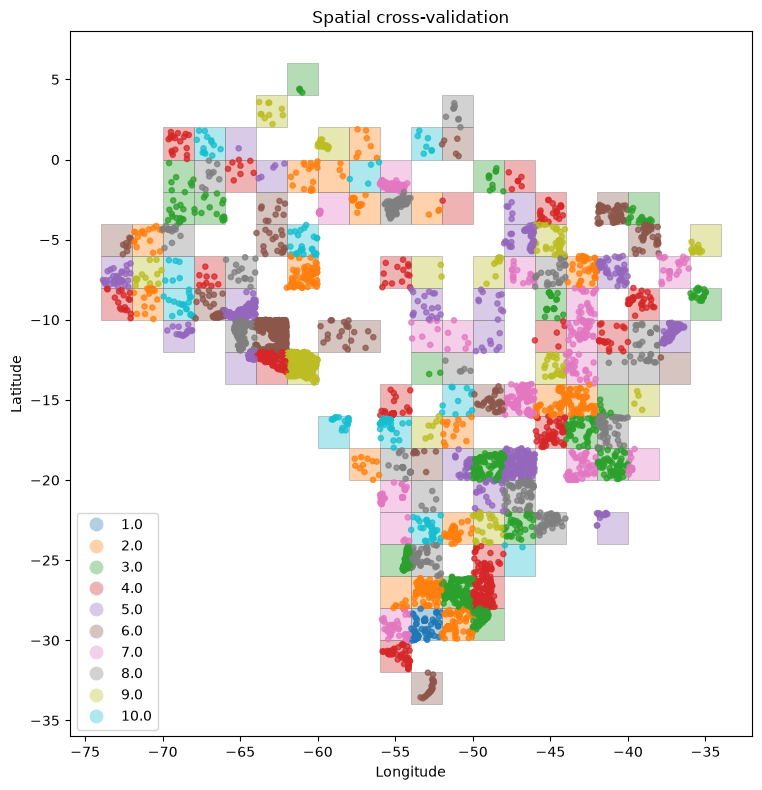

In [14]:
# Add fold information to block polygons.
block_info = (
    samples_model[
        ["block_id", "dataset", "fold"]
    ]
    .drop_duplicates("block_id")
)

blocks_plot = blocks_gdf.merge(
    block_info,
    on="block_id",
    how="left"
)

# Plot training folds.
fig, ax = plt.subplots(figsize=(10, 8))

training_blocks_plot = blocks_plot[
    blocks_plot["dataset"] == "Training"
].copy()

training_points_plot = samples_model[
    samples_model["dataset"] == "Training"
].copy()

training_blocks_plot.plot(
    ax=ax,
    column="fold",
    categorical=True,
    alpha=0.35,
    edgecolor="0.35",
    linewidth=0.6,
    legend=True,
)

training_points_plot.plot(
    ax=ax,
    column="fold",
    categorical=True,
    markersize=14,
    alpha=0.75,
)

ax.set_title("Spatial cross-validation")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

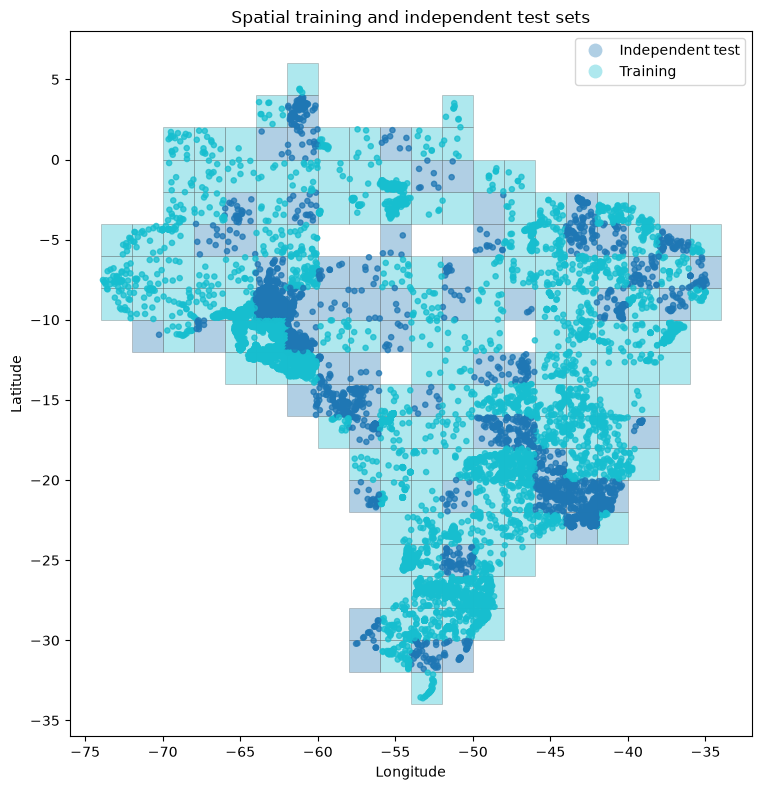

In [15]:
# Plot spatial training and test sets.
fig, ax = plt.subplots(figsize=(10, 8))

blocks_plot.plot(
    ax=ax,
    column="dataset",
    categorical=True,
    alpha=0.35,
    edgecolor="0.35",
    linewidth=0.6,
    legend=True,
)

samples_model.plot(
    ax=ax,
    column="dataset",
    categorical=True,
    markersize=14,
    alpha=0.75,
)

ax.set_title("Spatial training and independent test sets")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## 9. Build explicit scikit-learn spatial CV indices

scikit-learn accepts a custom cross-validation as a list of `(train_indices, validation_indices)` pairs. We build this list from the fold of each training sample and check that no block is shared between the training and validation parts of any fold.

In [16]:
# Create response and predictor matrices.
X = samples_df.drop(columns="areia")
y = samples_df["areia"]

train_mask = (
    samples_model["dataset"] == "Training"
).to_numpy()

test_mask = (
    samples_model["dataset"] == "Independent test"
).to_numpy()

X_train = X.loc[train_mask].reset_index(drop=True)
X_test = X.loc[test_mask].reset_index(drop=True)

y_train = y.loc[train_mask].reset_index(drop=True)
y_test = y.loc[test_mask].reset_index(drop=True)

train_spatial = (
    samples_model.loc[train_mask]
    .reset_index(drop=True)
)

test_spatial = (
    samples_model.loc[test_mask]
    .reset_index(drop=True)
)

print("Training samples:", len(X_train))
print("Independent test samples:", len(X_test))

Training samples: 9455
Independent test samples: 4181


In [17]:
# ============================================================
# BUILD SCIKIT-LEARN SPATIAL CV INDICES
# ============================================================

training_fold_id = train_spatial["fold"].astype(int).to_numpy()

spatial_cv = []

for fold in range(1, k_folds + 1):
    validation_idx = np.flatnonzero(
        training_fold_id == fold
    )
    train_idx = np.flatnonzero(
        training_fold_id != fold
    )

    spatial_cv.append(
        (train_idx, validation_idx)
    )

# Check index sizes.
cv_index_summary = pd.DataFrame({
    "Fold": np.arange(1, k_folds + 1),
    "Training samples": [
        len(train_idx)
        for train_idx, _ in spatial_cv
    ],
    "Validation samples": [
        len(validation_idx)
        for _, validation_idx in spatial_cv
    ],
})

display(cv_index_summary)

,Fold,Training samples,Validation samples
0,1,8435,1020
1,2,8517,938
2,3,8517,938
3,4,8518,937
4,5,8518,937
5,6,8518,937
6,7,8519,936
7,8,8517,938
8,9,8518,937
9,10,8518,937


In [18]:
# Check block leakage within each fold.
for fold, (train_idx, validation_idx) in enumerate(
    spatial_cv,
    start=1
):
    train_blocks_fold = set(
        train_spatial.loc[train_idx, "block_id"]
    )
    validation_blocks_fold = set(
        train_spatial.loc[validation_idx, "block_id"]
    )

    overlap = train_blocks_fold & validation_blocks_fold

    if overlap:
        raise RuntimeError(
            f"Spatial leakage detected in Fold {fold}."
        )

print(
    "Spatial leakage check passed: "
    "no block is shared between training and validation."
)

Spatial leakage check passed: no block is shared between training and validation.


## 10. Train and tune the Random Forest model

Same model and hyperparameter grid as in Part 3, but tuned with the spatial folds. The hyperparameters are now chosen for their ability to predict **new regions**, which can favor a different combination than the random CV.

In [19]:
# Define the Random Forest model.
model_rf = RandomForestRegressor(
    n_estimators=200,
    max_features="sqrt",
    min_samples_leaf=5,
    random_state=123,
    n_jobs=-1
)

# Keep the original tuning grid.
param_grid = {
    "max_features": ["sqrt", 0.5, 1.0],
    "min_samples_leaf": [3, 5]
}

# Tune with predefined spatial folds.
grid_search = GridSearchCV(
    estimator=model_rf,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=spatial_cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# GridSearchCV refits the best model on all training data.
model_rf = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest spatial CV RMSE:")
print(-grid_search.best_score_)

Fitting 10 folds for each of 6 candidates, totalling 60 fits
Best parameters:
{'max_features': 'sqrt', 'min_samples_leaf': 5}

Best spatial CV RMSE:
22.9477737583235


## 11. Evaluate spatial cross-validation performance

Compare these metrics with the random cross-validation of Part 3. The difference measures how much the random validation overestimated the model's ability to predict unsampled regions.

In [20]:
# Generate spatially out-of-fold predictions.
pred_cv = cross_val_predict(
    model_rf,
    X_train,
    y_train,
    cv=spatial_cv,
    n_jobs=-1
)

# Calculate spatial CV metrics.
rmse_cv = mean_squared_error(y_train, pred_cv) ** 0.5
mae_cv = mean_absolute_error(y_train, pred_cv)
r2_cv = r2_score(y_train, pred_cv)

metrics_cv = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R²"],
    "Value": [rmse_cv, mae_cv, r2_cv]
})

display(metrics_cv)

,Metric,Value
0,RMSE,23.055026
1,MAE,19.001177
2,R²,0.305667


## 12. Examine variable importance

Permutation importance computed on the training data (see Part 3 for how it works). Compare the ranking with Part 3: predictors that only help interpolate between nearby samples tend to lose importance, while predictors that describe broad environmental gradients tend to gain it.

In [21]:
# Calculate permutation importance on training data.
perm_importance = permutation_importance(
    model_rf,
    X_train,
    y_train,
    n_repeats=10,
    random_state=123,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Importance": perm_importance.importances_mean
}).sort_values(
    "Importance",
    ascending=False
)

display(importance_df.head(20))

,Variable,Importance
2,NTSI,0.161824
19,bio6,0.073691
17,bio4,0.071678
10,bio15,0.059223
22,bio9,0.053629
20,bio7,0.052869
13,bio18,0.052868
7,bio12,0.052318
18,bio5,0.052151
16,bio3,0.051353


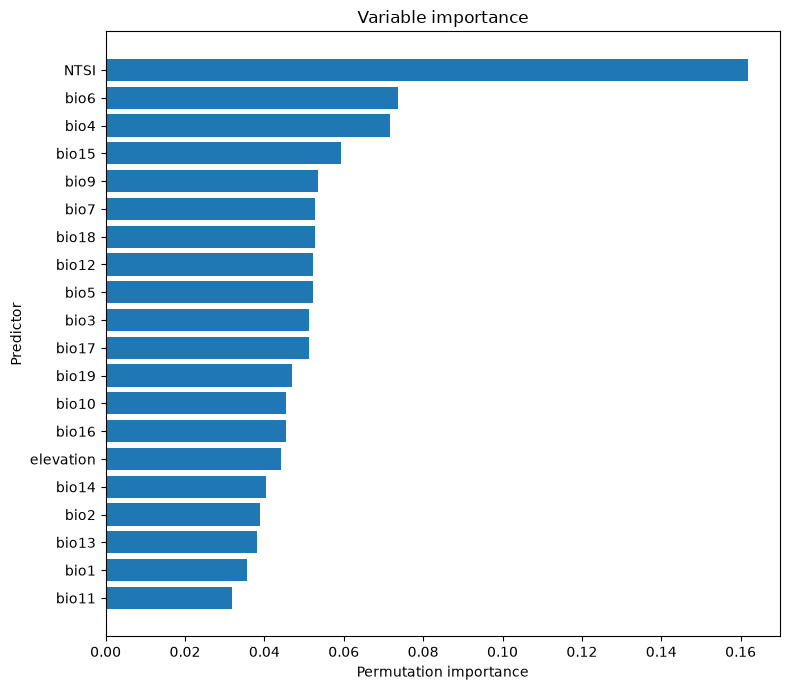

In [22]:
# Plot the most important predictors.
top_imp = importance_df.head(20).sort_values("Importance")

plt.figure(figsize=(8, 7))
plt.barh(top_imp["Variable"], top_imp["Importance"])
plt.xlabel("Permutation importance")
plt.ylabel("Predictor")
plt.title("Variable importance")
plt.tight_layout()
plt.show()

## 13. Predict the independent spatial test data

The model predicts the samples from the test blocks, which are regions it never saw.

In [23]:
# Predict unseen spatial blocks.
pred_test = model_rf.predict(X_test)

## 14. Evaluate the independent spatial test

This is the most realistic estimate of the map's accuracy in regions without samples.

| Validation | RMSE (%) | R² |
|---|---|---|
| Random CV (Part 3) | 17.4 | 0.58 |
| Random independent test (Part 3) | 17.3 | 0.59 |
| **Spatial CV** (this notebook) | **23.1** | **0.31** |
| **Spatial independent test** (this notebook) | **24.6** | **0.03** |

When the model has to predict regions it has never seen, the error grows by a third or more (RMSE from ~17 % to 23–25 %) and the explained variance collapses, and on the independent test blocks the model is barely better than predicting the mean. The random validation of Part 3 therefore greatly **overestimated** the map's accuracy away from the samples: much of that apparent skill came from interpolating between nearby, spatially autocorrelated samples.

The gap between spatial CV (R² ≈ 0.31) and the spatial test (R² ≈ 0.03) also shows that the performance in new regions depends heavily on *which* regions are left out: some blocks resemble the training data, others do not.

In [24]:
# Calculate independent spatial-test metrics.
rmse_test = mean_squared_error(y_test, pred_test) ** 0.5
mae_test = mean_absolute_error(y_test, pred_test)
r2_test = r2_score(y_test, pred_test)

metrics_test = pd.DataFrame({
    "Dataset": ["Independent spatial test"],
    "RMSE": [rmse_test],
    "R2": [r2_test],
    "MAE": [mae_test]
})

display(metrics_test)

,Dataset,RMSE,R2,MAE
0,Independent spatial test,24.605937,0.033962,19.697703


## 15. Compare observed and predicted values

Points on the dashed 1:1 line are perfect predictions.

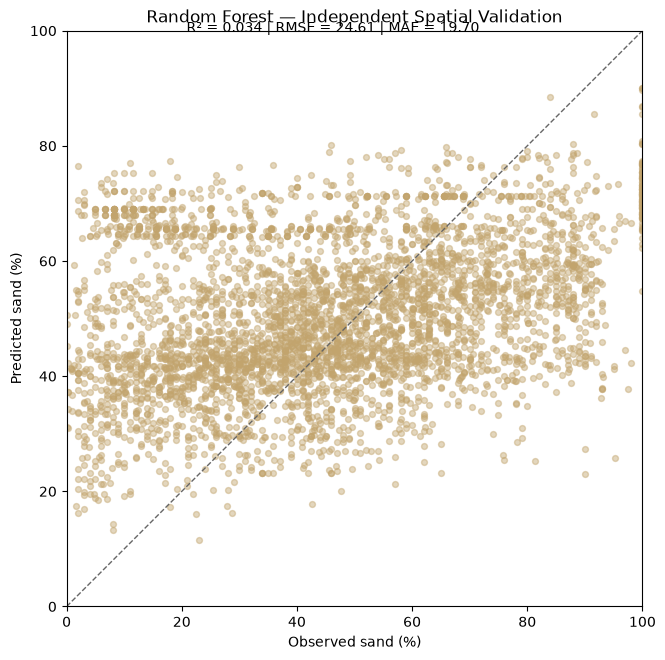

In [25]:
# Define common axis limits.
lims = [
    min(y_test.min(), pred_test.min()),
    max(y_test.max(), pred_test.max())
]

# Plot observed versus predicted values.
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    pred_test,
    s=18,
    alpha=0.45,
    c="#C2A46D"
)

plt.plot(
    lims,
    lims,
    linestyle="--",
    linewidth=1.0,
    color="0.4"
)

plt.xlim(lims)
plt.ylim(lims)
plt.gca().set_aspect("equal", adjustable="box")

plt.xlabel("Observed sand (%)")
plt.ylabel("Predicted sand (%)")
plt.title("Random Forest — Independent Spatial Validation")
plt.suptitle(
    f"R² = {r2_test:.3f} | RMSE = {rmse_test:.2f} | MAE = {mae_test:.2f}",
    y=0.92,
    fontsize=10
)

plt.tight_layout()
plt.show()

## 16. Apply the model to the raster predictors

Same procedure as in Part 3: match variables to rasters, check that all rasters share the same grid, and predict block by block. The map is written to `output/pred_areia_rf_spatialcv.tif`.

Note that changing the validation does not, by itself, make the map better; it makes its **accuracy estimate** more honest. Differences between the two maps come from the different hyperparameters selected by each validation.

In [26]:
# Identify predictors used during training.
predictor_names = list(X_train.columns)

# Match predictors to raster files.
raster_lookup = {f.stem: f for f in raster_files}

missing_vars = [
    name for name in predictor_names
    if name not in raster_lookup
]

if missing_vars:
    raise ValueError(
        "Missing raster predictors: " + ", ".join(missing_vars)
    )

predictor_rasters = [
    raster_lookup[name]
    for name in predictor_names
]

predictor_rasters

[PosixPath('input/HAND.tif'),
 PosixPath('input/Mean_curvature.tif'),
 PosixPath('input/NTSI.tif'),
 PosixPath('input/TPI_11x11.tif'),
 PosixPath('input/bio1.tif'),
 PosixPath('input/bio10.tif'),
 PosixPath('input/bio11.tif'),
 PosixPath('input/bio12.tif'),
 PosixPath('input/bio13.tif'),
 PosixPath('input/bio14.tif'),
 PosixPath('input/bio15.tif'),
 PosixPath('input/bio16.tif'),
 PosixPath('input/bio17.tif'),
 PosixPath('input/bio18.tif'),
 PosixPath('input/bio19.tif'),
 PosixPath('input/bio2.tif'),
 PosixPath('input/bio3.tif'),
 PosixPath('input/bio4.tif'),
 PosixPath('input/bio5.tif'),
 PosixPath('input/bio6.tif'),
 PosixPath('input/bio7.tif'),
 PosixPath('input/bio8.tif'),
 PosixPath('input/bio9.tif'),
 PosixPath('input/elevation.tif'),
 PosixPath('input/slope.tif')]

In [27]:
# Check that predictor rasters share the same grid.
reference_path = predictor_rasters[0]

with rasterio.open(reference_path) as ref:
    ref_profile = ref.profile.copy()
    ref_shape = (ref.height, ref.width)
    ref_transform = ref.transform
    ref_crs = ref.crs

for path in predictor_rasters[1:]:
    with rasterio.open(path) as src:
        if (src.height, src.width) != ref_shape:
            raise ValueError(f"Raster shape mismatch: {path.name}")
        # Compare with a tolerance: some rasters differ from the reference only by
        # floating-point noise in the geotransform (~1e-7 degrees, far below one pixel).
        if not src.transform.almost_equals(ref_transform, precision=1e-6):
            raise ValueError(f"Raster transform mismatch: {path.name}")
        if src.crs != ref_crs:
            raise ValueError(f"Raster CRS mismatch: {path.name}")

print("All predictor rasters share the same grid.")

All predictor rasters share the same grid.


In [28]:
# Predict the raster in blocks.
output_path = OUTPUT_DIR / "pred_areia_rf_spatialcv.tif"

output_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

with rasterio.open(reference_path) as ref:
    profile = ref.profile.copy()

profile.update(
    count=1,
    dtype="float32",
    nodata=np.nan,
    compress="deflate",
    predictor=3,
    zlevel=9
)

sources = [
    rasterio.open(path)
    for path in predictor_rasters
]

try:
    with rasterio.open(output_path, "w", **profile) as dst:

        for _, window in sources[0].block_windows(1):

            arrays = []
            valid_mask = None

            for src in sources:
                arr = src.read(
                    1,
                    window=window
                ).astype("float32")

                current_valid = np.isfinite(arr)

                if src.nodata is not None:
                    current_valid &= arr != src.nodata

                valid_mask = (
                    current_valid
                    if valid_mask is None
                    else valid_mask & current_valid
                )

                arrays.append(arr)

            block_shape = arrays[0].shape
            output_block = np.full(
                block_shape,
                np.nan,
                dtype="float32"
            )

            if np.any(valid_mask):
                X_block = np.column_stack([
                    arr[valid_mask]
                    for arr in arrays
                ])

                pred_block = model_rf.predict(
                    pd.DataFrame(
                        X_block,
                        columns=predictor_names
                    )
                )

                output_block[valid_mask] = pred_block.astype("float32")

            dst.write(
                output_block,
                1,
                window=window
            )

finally:
    for src in sources:
        src.close()

print(f"Prediction saved to: {output_path}")

/tmp/ipykernel_1207/4179270924.py:35: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.read(
/tmp/ipykernel_1207/4179270924.py:35: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.read(
/tmp/ipykernel_1207/4179270924.py:35: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.read(
/tmp/ipykernel_1207/4179270924.py:35: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.read(
/tmp/ipykernel_1207/4179270924.py:35: DeprecationWarning

Prediction saved to: output/pred_areia_rf_spatialcv.tif


/tmp/ipykernel_1207/4179270924.py:35: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arr = src.read(


## 17. Display the prediction map

Predicted sand content (%) for every pixel where all predictors are available.

/tmp/ipykernel_1207/2488468849.py:3: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  pred_map = src.read(1)


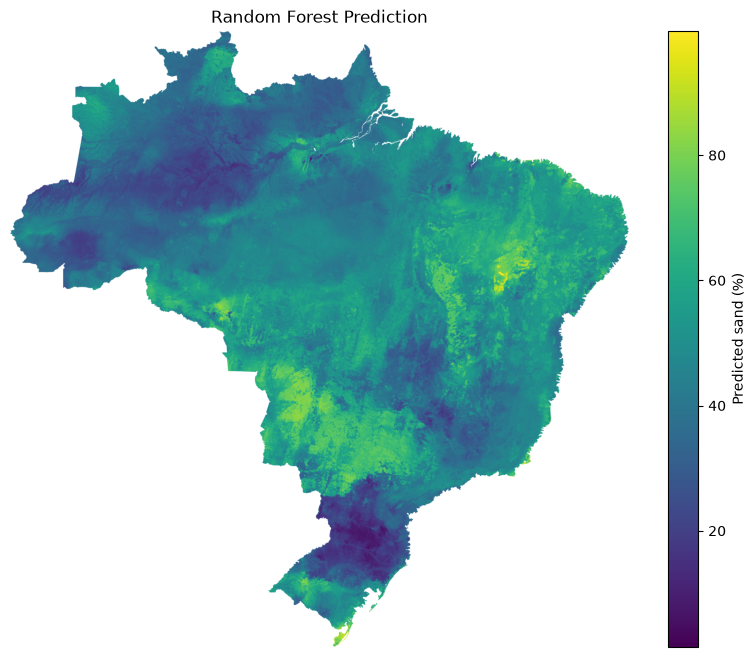

In [29]:
# Display the prediction raster.
with rasterio.open(output_path) as src:
    pred_map = src.read(1)

plt.figure(figsize=(10, 8))
plt.imshow(pred_map)
plt.colorbar(label="Predicted sand (%)")
plt.title("Random Forest Prediction")
plt.axis("off")
plt.show()

## 18. Final spatial-CV checks

A last consistency check: no block is shared between training and test, nor between the training and validation parts of any cross-validation fold.

In [30]:
# Check train/test block separation.
assert not (
    set(train_spatial["block_id"])
    & set(test_spatial["block_id"])
)

# Check every CV fold.
for train_idx, validation_idx in spatial_cv:
    assert not (
        set(train_spatial.loc[train_idx, "block_id"])
        & set(train_spatial.loc[validation_idx, "block_id"])
    )

print("FINAL CHECK PASSED")
print("- no block is shared between training and test")
print("- no block is shared within a CV split")
print("- GridSearchCV used the predefined spatial folds")

FINAL CHECK PASSED
- no block is shared between training and test
- no block is shared within a CV split
- GridSearchCV used the predefined spatial folds


## Summary

- With spatial blocks, the Random Forest explains only **~31 % (spatial CV) to ~3 % (spatial test)** of the variance of sand content, compared with ~58 % under random validation (Part 3).
- The selected hyperparameters also change (`max_features = "sqrt"`, `min_samples_leaf = 5`): smoother, less local models perform better when predicting new regions.
- `NTSI` remains the most important predictor, but its dominance and the importance of all variables decrease.
- **Take-home message:** with spatially autocorrelated data, random cross-validation measures the ability to *interpolate* near the samples. To estimate the accuracy of a map in unsampled regions, the validation must be spatial.